In [1]:
from common import *
from collections import defaultdict
from uncertainties import ufloat
from scipy import stats
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
from sklearn import metrics
from pprint import pprint

get(
    "machinable.index",
    "./index",
).__enter__()

machinable.index [2474ef]

# Random

In [5]:
_mn_random = get('interface._mn_random')

globus_download(_mn_random)

### How many samples are feasible?

In [28]:
fs = defaultdict(list)
for experiment in _mn_random.components:
    wide_range = 'wide_ranges' in experiment.version()[0]
    constraints = experiment.load_h5()['constraints']
    c = (constraints.to_numpy() > 0).astype(int)
    
    # append global
    r = np.concatenate((c, c.all(axis=1).astype(int).reshape(-1, 1)), axis=1)

    blocks = []
    for slice in range(5):
        region = 1000
        m = r[slice*region:(slice+1)*region]
        m = m.sum(axis=0)
        blocks.append(m)

    # global sum
    r = r.sum(axis=0) / r.shape[0] * 100

    fs[experiment.config.dopt_params.initial_method + "_" + ('wr' if wide_range else 'nr')].append(r.tolist())


In [29]:
stash("figure4-fs", dict(fs))
stash('figure4-constraint_columns', constraints.columns.tolist())

In [30]:
fs = restore('figure4-fs')
constraint_columns = restore('figure4-constraint_columns')

Text(0.5, 1.0, 'Percent of samples that meet constraint')

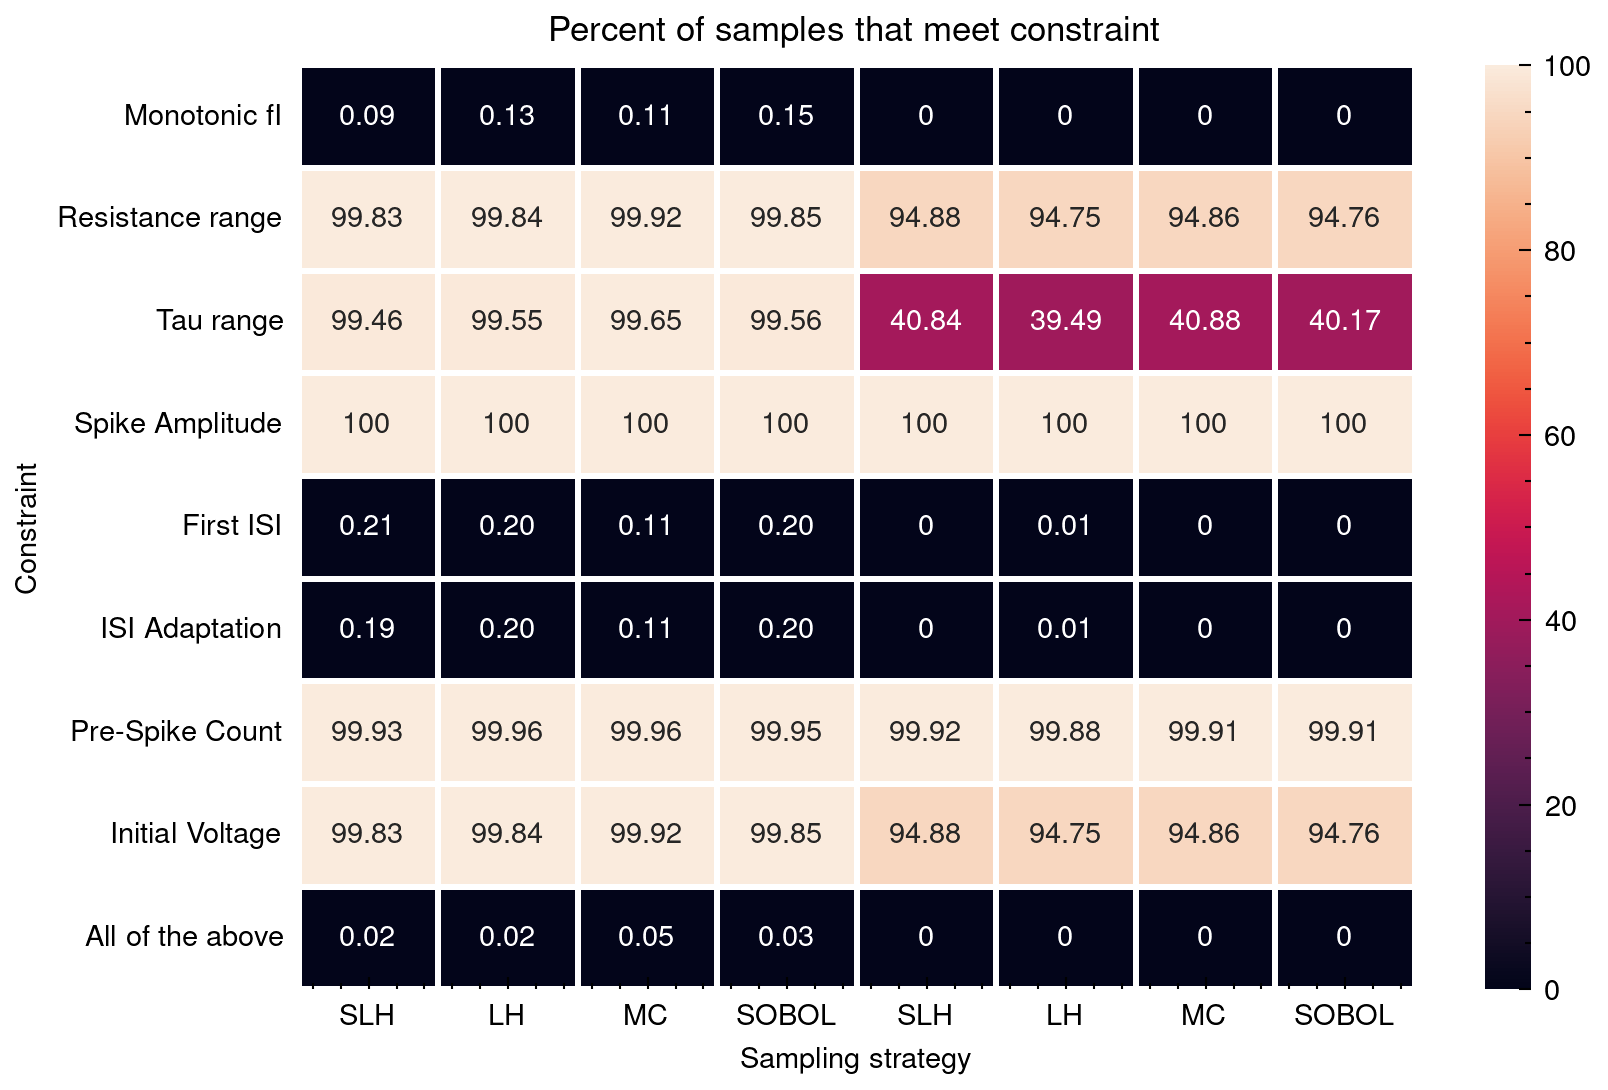

In [37]:
import seaborn as sns
from uncertainties import unumpy
import pandas as pd

fig = plt.figure(figsize=(6, 4))

plt.rcParams["xtick.top"] = False
plt.rcParams["ytick.left"] = False
plt.rcParams["ytick.right"] = False

plt.rcParams['ytick.labelright'] = False
plt.rcParams['ytick.labelleft'] = True

data  = np.array([
    unumpy.uarray(np.array(v).mean(axis=0), np.array(v).std(axis=0)) 
    for k, v in fs.items() #if k.endswith('_wr') or k == 'mc_nr'
]).T

sns.heatmap(
    unumpy.nominal_values(data),
    annot=pd.DataFrame(data).map(lambda x: f"{x.n:.2f}" if x != 100. and x!=0.0 else {0.0: '0', 100: "100"}[x.n]),
    fmt='s',
    xticklabels=[k.upper().replace('_WR', '').replace('_NR', '')
                 for k in fs.keys() #if k.endswith('_wr') or k == 'mc_nr'
                 ],
    yticklabels=[{
        'monotonic_fI': 'Monotonic fI',
        'rn_constr': 'Resistance range',
        'tau_constr': 'Tau range',
        'spike_amplitude_constr': 'Spike Amplitude',
        'first_ISI_constr': 'First ISI',
        'ISI_adaptation_constr': 'ISI Adaptation',
        'pre_spk_count': 'Pre-Spike Count',
        'initial_v_constr': 'Initial Voltage'
        }[k] for k in constraint_columns] + ["All of the above"],
    vmin=0,
    vmax=100,
    linewidths=1,
)
plt.xlabel("Sampling strategy")
plt.ylabel("Constraint")
plt.title("Percent of samples that meet constraint")

In [39]:
stash("figure4/random-sampling-constraints", fig)

# Baseline vs Gradient wide range

In [2]:
_mn_sopt_grad = get("interface._mn_sopt_grad")

globus_download(_mn_sopt_grad)

numprocs=1


2025-07-20 09:46:17.943981: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-20 09:46:17.965709: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-20 09:46:17.965748: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-20 09:46:17.981238: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-20 09:46:19.223901: W tensorflow/compiler/tf

In [3]:
nadirs = {}
mn_sopt_grad_hvs = {}

experiments = _mn_sopt_grad.components.filter(lambda x: x.cached())

# combine wide-ranges
grad_nadir = fronts_nadir(experiments)
sopt_nadir = fronts_nadir(get("interface._mn_sopt_baseline", {'ranges': False}).components.filter(
    lambda x: x.cached() and not x.load_attribute("preflight", False)
))
nadirs['MN-r'] = [float(max(a,b)) for a,b in zip(grad_nadir, sopt_nadir)]


for experiment in experiments:
    model_name = experiment.load_attribute("model_name")
    
    epoch_ranges = experiment.epoch_ranges(from_zero=True)

    mn_sopt_grad_hvs.setdefault(model_name, {})
    for epoch, region in enumerate(epoch_ranges):
        mn_sopt_grad_hvs[model_name].setdefault(epoch, [])
        hv = experiment.norm_hv_region(nadirs['MN-r'], region)
        mn_sopt_grad_hvs[model_name][epoch].append(hv)

In [4]:
for ranges in [True, False]:
    globus_download(get("interface._mn_sopt_baseline", {'ranges': ranges}))

In [5]:
baseline_hvs = defaultdict(dict)
nos_hv = defaultdict(list)
igds = defaultdict(dict)


def _name(experiment):
    n = (
        experiment.label()
        .split("_neuron::")[-1][2:]
        .split("/")[0]
        .replace("joint-", "")
    )
    if "o" in n:
        n += (
            "-"
            + experiment.config.dopt_params.surrogate_custom_training_kwargs.backbone
        )
    return n


for ranges in [False, True]:
    _mn_sopt_baseline = get("interface._mn_sopt_baseline", {'ranges': ranges})

    p = "MN-r" if ranges else 'MN' 

    experiments = _mn_sopt_baseline.components.filter(
        lambda x: x.cached() and not x.load_attribute("preflight", False)
    )
    if p == 'MN':
        nadir = nadirs[p] = fronts_nadir(experiments)
    else:
        nadir = nadirs[p]
    
    tracking = {"interfaces": []}

    for experiment in experiments:
        model_name = _name(experiment)

        epoch_ranges = experiment.epoch_ranges(from_zero=True)

        if model_name == "-":
            tracking["interfaces"].append(experiment)
            continue

        if model_name == "gpr":
            tracking["ranges"] = epoch_ranges

        baseline_hvs[p].setdefault(model_name, {})
        for epoch, region in enumerate(epoch_ranges):
            baseline_hvs[p][model_name].setdefault(str(epoch), [])
            hv = experiment.norm_hv_region(nadir, region)
            baseline_hvs[p][model_name][str(epoch)].append(hv)

    # backfill eval-normalized baseline
    baseline_hvs[p]["baseline"] = {}
    for epoch, region in enumerate(tracking["ranges"]):
        baseline_hvs[p]["baseline"][str(epoch)] = [
            i.norm_hv_region(nadir, region) for i in tracking["interfaces"]
        ]

    # compute nos hv after 25 epochs
    for i in tracking["interfaces"]:
        nos_hv[p + "10"].append(
            i.norm_hv_region(nadir, i.epoch_ranges(from_zero=True)[10])
        )
        nos_hv[p].append(i.norm_hv(nadir))

    # compute igds
    for experiment in experiments:
        model_name = _name(experiment)
        igds[p][model_name] = [float(experiment.igd(i)) for i in tracking["interfaces"]]

In [6]:
initial_samples = {
    'MN': _mn_sopt_baseline.components.filter(
        lambda x: not x.load_attribute("preflight", False)
    )
    .first()
    .num_initial_samples
}
initial_samples['MN-r'] = initial_samples['MN']

In [7]:
initial_samples

{'MN': 1100, 'MN-r': 1100}

In [8]:
nadirs

{'MN-r': [185153.625, 31010.28125, 15848.29296875, 3600.0],
 'MN': [110398.8984375, 2464.8564453125, 15848.29296875, 341.0312805175781]}

In [9]:
support_benchmark = {
   'surrogate_equivalent': [],
   'best_overall': []
}
eval_normed_region = tracking["ranges"][-1]

for nos_experiment in tracking["interfaces"]:
    support_benchmark['surrogate_equivalent'].append(
        nos_experiment.get_best(region=eval_normed_region)
    )
    support_benchmark['best_overall'].append(
        nos_experiment.get_best()
    )

In [ ]:
stash("figure4-nos_hv", nos_hv)
stash("figure4-nadirs", nadirs)
stash("figure4-baseline_hvs", baseline_hvs)
stash("figure4-mn_sopt_grad_hvs", mn_sopt_grad_hvs)
stash("figure4-igds", igds)
stash("figure4-initial_samples", initial_samples)
stash('figure4-support-benchmark.p', support_benchmark)

In [2]:
nadirs = restore("figure4-nadirs")
nos_hv = restore("figure4-nos_hv")
baseline_hvs = restore("figure4-baseline_hvs")
mn_sopt_grad_hvs = restore("figure4-mn_sopt_grad_hvs")
igds = restore("figure4-igds")
initial_samples = restore("figure4-initial_samples")
support_benchmark = restore('figure4-support-benchmark.p')

/tmp/ipykernel_3042478/1836536930.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


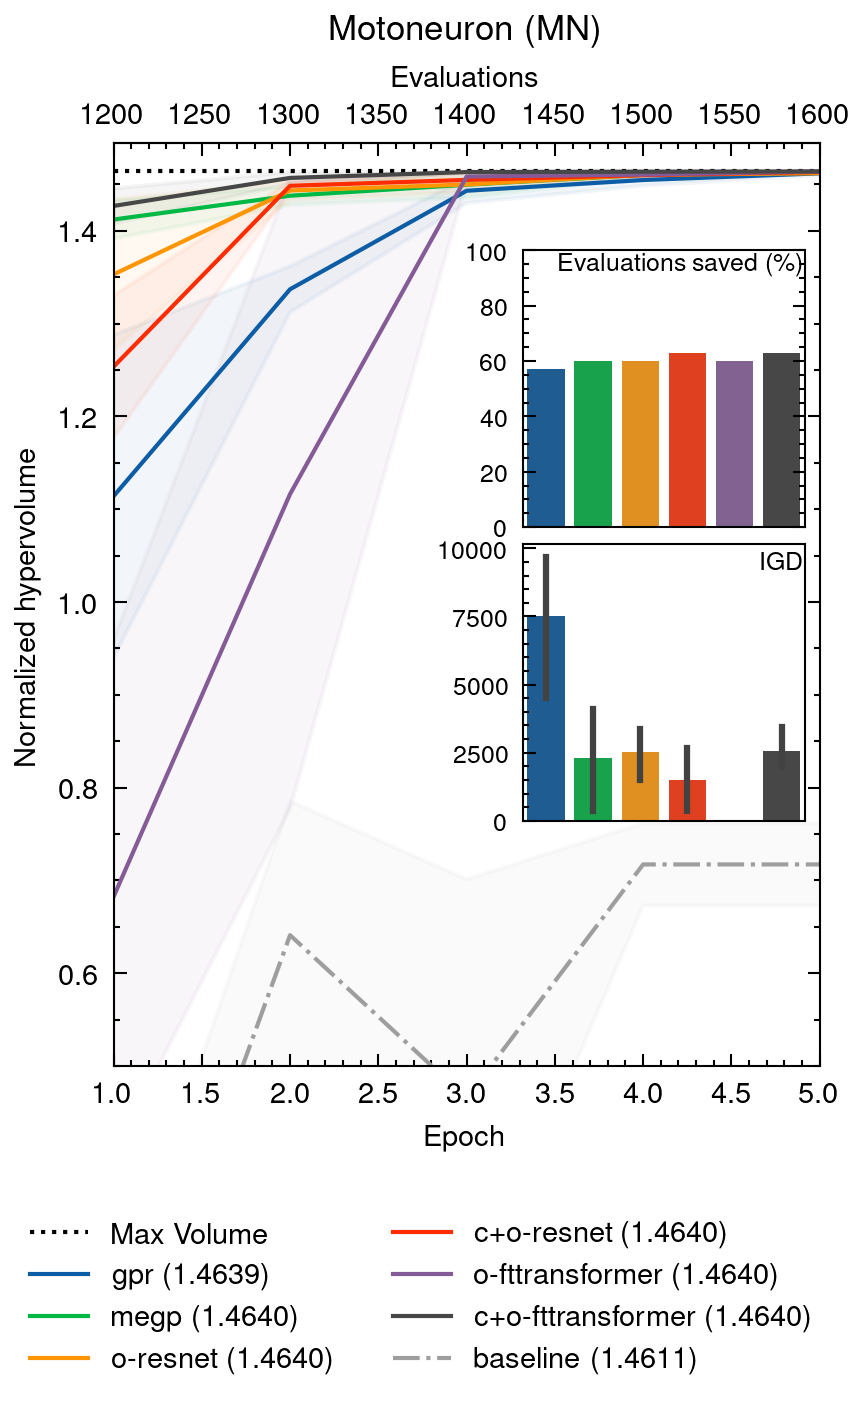

In [11]:
plt.rcParams["xtick.top"] = False
plt.rcParams["ytick.left"] = True
plt.rcParams["ytick.right"] = True
# plt.rcParams['axes.spines.top'] = False

plt.rcParams['ytick.labelright'] = False
plt.rcParams['ytick.labelleft'] = True


fig, ax = plt.subplots(1, 1, figsize=(3, 4))

p = 'MN'
models = baseline_hvs[p]

nos_mean = np.mean(nos_hv[p + "10"])
nos_err = stats.sem(nos_hv[p + "10"])

ax.axhline(y=1.1**4, color="black", linestyle=":", label="Max Volume")

# determine when surrogate reaches within 1% of non-surrogate HV
converged = {}
for i, (model_name, epoch_hvs) in enumerate(models.items()):
    for epoch, hvs in epoch_hvs.items():
        epoch = int(epoch)
        converged[model_name] = [0]
        if epoch > 1 and np.mean(hvs) > 0.99 * np.mean(
            baseline_hvs[p]["baseline"]["24"]
        ):
            converged[model_name] = [(24-epoch)*100/(initial_samples[p]+100*24)*100]
            break

for i, (model_name, epoch_hvs) in enumerate(models.items()):
    x = []
    y = []
    y_err = []
    yy = defaultdict(list)
    y_all = []
    for epoch, hvs in epoch_hvs.items():
        epoch = int(epoch)
        y_all.append(np.mean(hvs))
        if epoch == 0 or epoch > 100:
            continue
        x.append(int(epoch))
        y.append(np.mean(hvs))
        y_err.append(stats.sem(hvs))
        for q in range(len(hvs)):
            yy[q].append(hvs[q])

    y_err = np.array(y_err)
    y = np.array(y)

    label = f"{model_name} ({ufloat(y[-1], y_err[-1]).n:.4f})"

    # ax.errorbar(x, y, yerr=y_err, label=model_name + f" ({ufloat(y[-1], y_err[-1])})", linestyle='-', capsize=1)
    ls_f = '-' # (0, (1,2))
    ax.plot(
        np.array(x)[np.array(x) < 25],
        np.array(y)[np.array(x) < 25],
        color=icolors[i],
        alpha=None if p == 'MN' or model_name == "baseline" else 0.9,
        label=label,
        linestyle=('-' if p == 'MN' or model_name == "baseline" else ls_f) if model_name != "baseline" else "dashdot",
    )

    ax.fill_between(x, y-y_err, y+y_err, alpha=0.05, color=icolors[i])

# igd
axigd = inset_axes(
    ax,
    width="40%",
    height="30%",
    loc=f"lower right",
    bbox_to_anchor=(0, 0.25, 1, 1),
    bbox_transform=ax.transAxes,
)
sns.barplot(pd.DataFrame(igds[p]).drop("-", axis=1), ax=axigd)
axigd.set_title("IGD", loc="right", y=1.0, pad=-6, fontsize=6)
axigd.tick_params(top=False, bottom=False, left=True, right=True, labelsize=6)
axigd.set_xticks([])
axigd
axigd.yaxis.tick_left()
axigd.yaxis.set_label_position("left")

# savings
axsave = inset_axes(
    ax,
    width="40%",
    height="30%",
    loc=f"upper right",
    bbox_to_anchor=(0, -0.1, 1, 1),
    bbox_transform=ax.transAxes,
)
sns.barplot(pd.DataFrame(converged).drop("baseline", axis=1), ax=axsave)
axsave.set_title("Evaluations saved (\\%)", loc="right", y=1.0, pad=-5, fontsize=6)
axsave.tick_params(top=False, bottom=False, left=True, right=True, labelsize=6)
axsave.set_xticks([])
axsave.set_ylim([0, 100])#25.5])
#axsave.set_yticks([0, 10, 20, 25])

# ax.axhline(y=nos_mean, color="red", linestyle=":", label=f"NoS ({ufloat(nos_mean, nos_err)})")
# ax.fill_between(x, [nos_mean - nos_err] * len(x), [nos_mean + nos_err] * len(x), color="red", alpha=0.1)

# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel("Epoch")
ax.set_xlim([0, 25])

# ax.legend(loc='best')
ax.tick_params(top=False)

secax = ax.secondary_xaxis(
    "top",
    functions=(
        lambda x, ins=initial_samples[p]: x * 100 + ins,
        lambda x, ins=initial_samples[p]: (x + ins) / 100,
    ),
)
secax.set_xlabel("Evaluations")

# ax.set_ylim(0, 1.1**4 * 1.05)
ax.set_title(
    'Motoneuron (MN)'
)  # loc='left', y=1.0, pad=-6)
ax.set_ylim([0.5, 1.1**4 + 0.03])

    
ax.set_ylabel("Normalized hypervolume")

ax.set_xlim([1, 5])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(labels)//3, 
           bbox_to_anchor=(0.95, -0.01))
#fig.legend(bbox_to_anchor=(0.95, -0.01))

plt.tight_layout()
plt.show()

In [25]:
stash('figure4/baseline-sopt', fig)

In [ ]:
# todo: wide-range sopt

/home/frithjof/Workspace/MultiObjectiveSurrogateOptimization/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/frithjof/Workspace/MultiObjectiveSurrogateOptimization/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


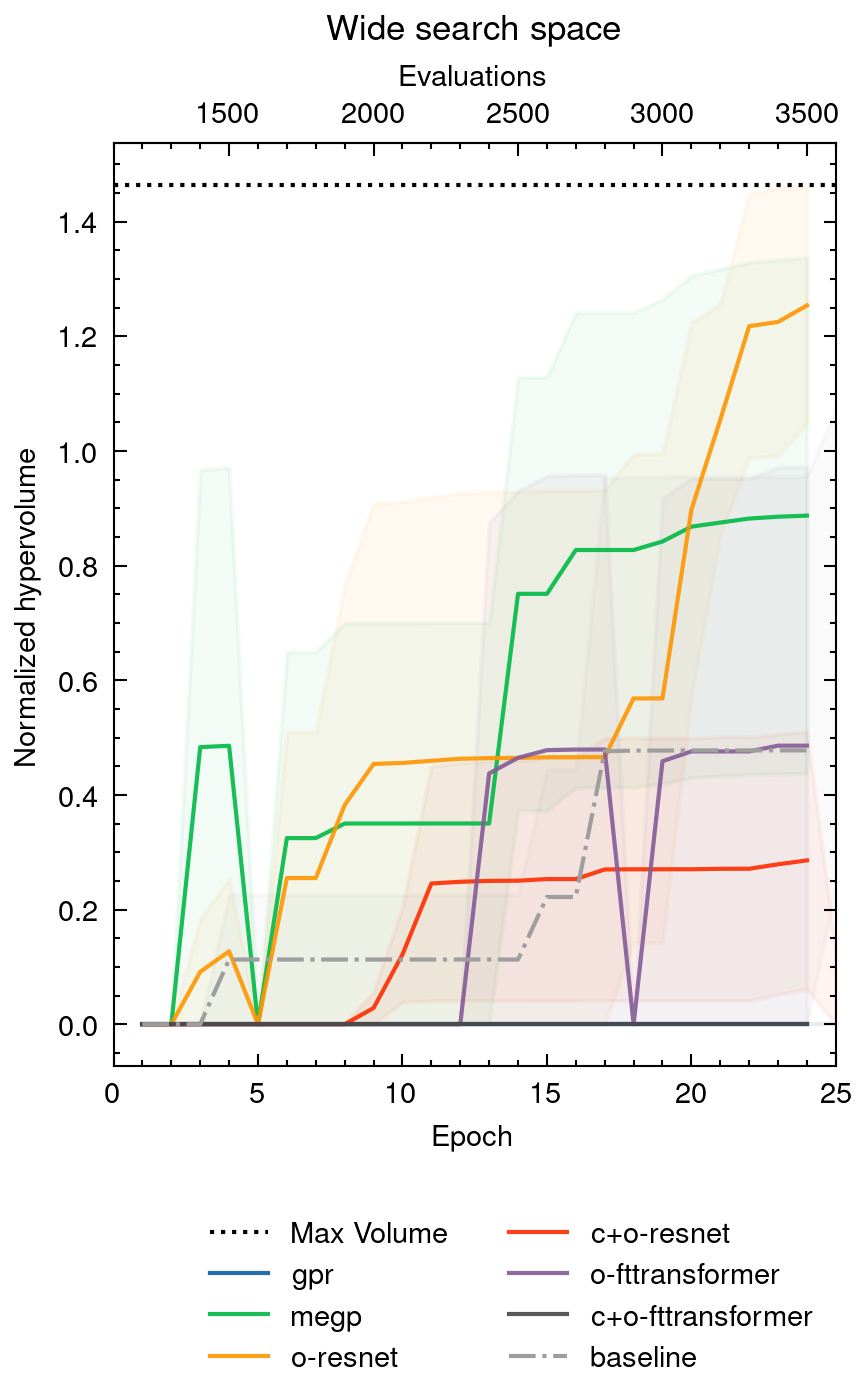

In [28]:
plt.rcParams["xtick.top"] = False
plt.rcParams["ytick.left"] = True
plt.rcParams["ytick.right"] = True
# plt.rcParams['axes.spines.top'] = False

plt.rcParams['ytick.labelright'] = False
plt.rcParams['ytick.labelleft'] = True


fig, ax = plt.subplots(1, 1, figsize=(3, 4))

p = 'MN-r'
models = baseline_hvs[p]

nos_mean = np.mean(nos_hv[p + "10"])
nos_err = stats.sem(nos_hv[p + "10"])

ax.axhline(y=1.1**4, color="black", linestyle=":", label="Max Volume")



for i, (model_name, epoch_hvs) in enumerate({
    k:models[k] for k in [ 'gpr', 'megp', 'o-resnet', 'c+o-resnet', 'o-fttransformer', 'c+o-fttransformer', 'baseline']
}.items()):
    x = []
    y = []
    y_err = []
    yy = defaultdict(list)
    y_all = []
    for epoch, hvs in epoch_hvs.items():
        epoch = int(epoch)
        y_all.append(np.mean(hvs))
        if epoch == 0 or epoch > 100:
            continue
        x.append(int(epoch))
        y.append(np.mean(hvs))
        y_err.append(stats.sem(hvs))
        for q in range(len(hvs)):
            yy[q].append(hvs[q])

    y_err = np.array(y_err)
    y = np.array(y)

    label = model_name  # str(ufloat(y[-1], y_err[-1]) / ufloat(nos_mean, nos_err) * 100) + '%'

    # ax.errorbar(x, y, yerr=y_err, label=model_name + f" ({ufloat(y[-1], y_err[-1])})", linestyle='-', capsize=1)


    ax.plot(
        np.array(x)[np.array(x) < 25],
        np.array(y)[np.array(x) < 25],
        color=icolors[i],
        alpha=None if p == 'MN' or model_name == "baseline" else 0.9,
        label=label,
        linestyle='-' if model_name != "baseline" else "dashdot",
    )

    ax.fill_between(x, y-y_err, y+y_err, alpha=0.05, color=icolors[i])



# ax.axhline(y=nos_mean, color="red", linestyle=":", label=f"NoS ({ufloat(nos_mean, nos_err)})")
# ax.fill_between(x, [nos_mean - nos_err] * len(x), [nos_mean + nos_err] * len(x), color="red", alpha=0.1)

# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel("Epoch")
ax.set_xlim([0, 25])

# ax.legend(loc='best')
ax.tick_params(top=False)

secax = ax.secondary_xaxis(
    "top",
    functions=(
        lambda x, ins=initial_samples[p]: x * 100 + ins,
        lambda x, ins=initial_samples[p]: (x + ins) / 100,
    ),
)
secax.set_xlabel("Evaluations")

# ax.set_ylim(0, 1.1**4 * 1.05)
ax.set_title('Wide search space')  # loc='left', y=1.0, pad=-6)
#ax.set_ylim([0.5, 1.1**4 + 0.03])

    
ax.set_ylabel("Normalized hypervolume")

#ax.set_xlim([1, 5])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(labels)//3, 
           bbox_to_anchor=(0.95, -0.01))
#fig.legend(bbox_to_anchor=(0.95, -0.01))

plt.tight_layout()
plt.show()

In [29]:
stash('figure4/baseline-and-wide-range', fig)

# Surrogate gradient descent

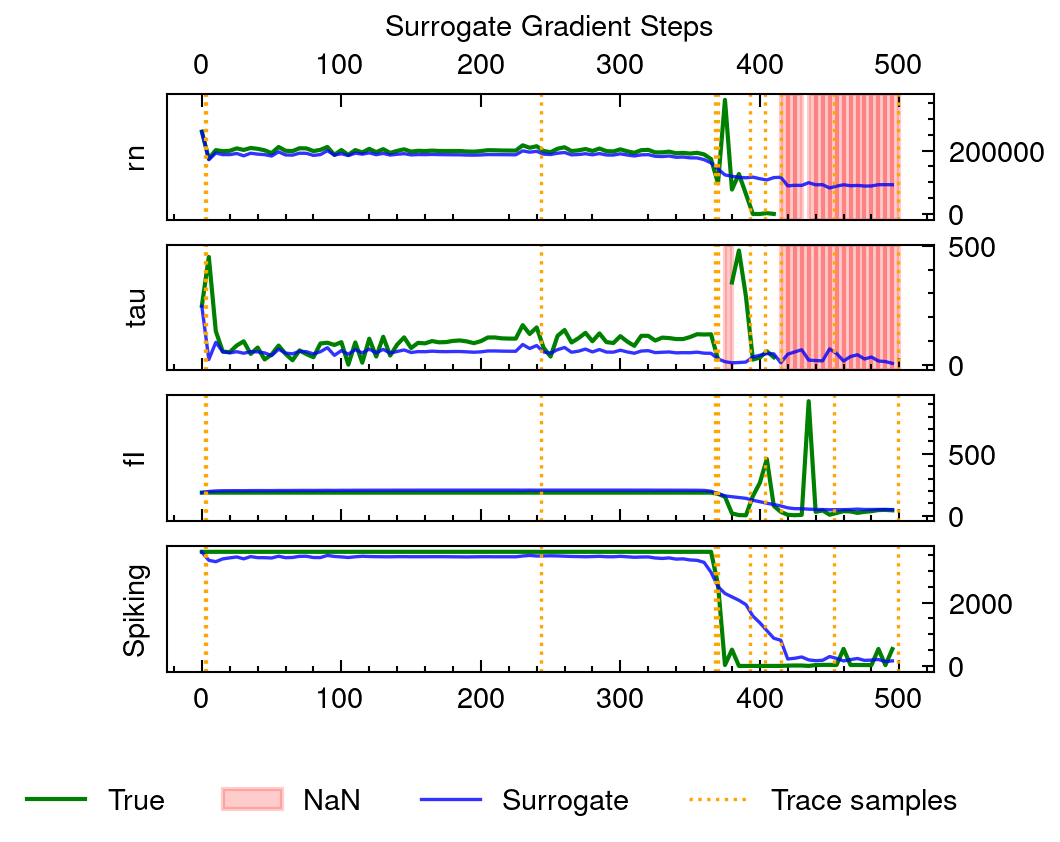

In [38]:
from models.ops import filter_array_by_distance
from machinable.utils import load_file
from scipy.stats import zscore
import numpy as np

evaluations = load_file('figures/data/figure4-sopt-grad-traces.p')

plt.rcParams["xtick.top"] = False
plt.rcParams["ytick.left"] = False
plt.rcParams["ytick.right"] = False

plt.rcParams['ytick.right'] = plt.rcParams['ytick.labelright'] = True
plt.rcParams['ytick.left'] = plt.rcParams['ytick.labelleft'] = False

real = []
surr = []

for point, y_pred, batch in evaluations:
    real.append(
        np.array([b[0] for b in batch])
    )
    surr.append(y_pred['objectives'])

real = np.array(real)
surr = np.array(surr)

# filter outliers
z_scores = np.abs(zscore(real, axis=0, nan_policy='omit'))
real[z_scores > 2] = np.nan


real_n = real / np.reshape(real, [-1, 4]).max(axis=0)
surr_n = surr / np.reshape(surr, [-1, 4]).max(axis=0)


fig, axs = plt.subplots(4, sharex=True)

objective_names = get('interface.sopt_modeling', "~from_protocol").objective_names

for batch in range(real_n.shape[1]):
    for c in range(real_n.shape[-1]):
        y = real[::5, batch, c]
        axs[c].plot(np.arange(len(y)*5)[::5], y, color='green',
                     label='True')

        # mark nans
        isnan = np.isnan(y)
        if np.any(isnan):
            nan_indices = np.where(isnan)[0]
            for idx in nan_indices:
                axs[c].axvspan(idx*5, (idx+1)*5, color='red',
                                alpha=0.2, label="NaN")
        
        y = surr[::5, batch, c]
        axs[c].plot(np.arange(len(y)*5)[::5], y, color='blue', 
                    linestyle='-', alpha=0.8, lw=0.8, label='Surrogate')

        _, _, idx = filter_array_by_distance(surr[:,batch], 10)
        for i in idx:
            axs[c].axvline(x=i, color='orange', label="Trace samples",
                           linestyle='dotted', alpha=1,
                           ymin=0, ymax=1, lw=0.8)

        axs[c].set_ylabel({
            'rn': 'rn',
            'tau': 'tau',
            'fI': 'fI',
            'spike_amplitude': 'Spiking'
        }[objective_names[c].replace('_error', '')])
        
    break

axs[0].set_xlabel('Surrogate Gradient Steps')
axs[0].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[0].xaxis.set_label_position('top') 

handles, labels = axs[0].get_legend_handles_labels()
unique = dict()
for h, l in zip(handles, labels):
    if l not in unique:
        unique[l] = h
handles, labels = list(unique.values()), list(unique.keys())
fig.legend(handles, labels, ncol=len(labels), 
           bbox_to_anchor=(0.95, -0.01))

In [39]:
stash("figure4/sopt-grad-sampling", fig)

## Pareto solution prediction accuracy

In [5]:
_mn_random = get("interface._mn_random")
experiment = _mn_random.components[0]

x_initial, y_initial, yC_initial = experiment.load_h5_arrays(
    region=[0, 1100])
x_random, y_random, yC_random = experiment.load_h5_arrays(
    region=[0, 1100+10])


x_trace, y_trace, yC_trace = experiment.load_h5_arrays(region=[0, 1100])
for i, (point, y_pred, batch) in enumerate(evaluations):
    if i not in idx:
        continue
    y, f, yC = batch[0]
    x = point[0]
    x_trace = np.vstack((x_trace, x))
    y_trace = np.vstack((y_trace, y))
    yC_trace = np.vstack((yC_trace, yC))

assert x_trace.shape == x_random.shape


In [31]:

from models.fttransformer import FTTransformer as Model
from sklearn.metrics import mean_absolute_error, median_absolute_error

tracing_pareto_prediction = {}

for key, x,y,C in [
    ('base', x_initial, y_initial, yC_initial),
    ('random', x_random, y_random, yC_random),
    ('trace', x_trace, y_trace, yC_trace),
]:
    model = Model(
        experiment.num_parameters,
        experiment.num_constraints,
        experiment.num_objectives,
        "c+o",
        experiment.xlb,
        experiment.xub,
    )

    wf = f"figures/data/figure4-tracing-eval-{key}.weights.h5"
    if os.path.isfile(wf):
        model.build()
        model.load_weights(wf)
        model.X_, model.y_, model.yC_ = model.preprocess(x, y, C)
    else:
        model.autofit(x, y, C, epochs='auto')
        model.save_weights(wf)

    bn = "best_overall"
    x_tests = []
    y_tests = []
    yC_tests = []

    for bi in range(3):
        x_tests.append(support_benchmark[bn][bi]['x'].to_numpy())
        y_tests.append(support_benchmark[bn][bi]['y'].to_numpy())
        yC_tests.append(support_benchmark[bn][bi]['c'].to_numpy())


    x_test = np.concatenate(x_tests, axis=0)
    y_test = np.concatenate(y_tests, axis=0)
    yC_test = np.concatenate(yC_tests, axis=0)


    y_pred = model.predict(x_test, verbose=0)['objectives']

    tracing_pareto_prediction[f"{key}_mae"] = float(mean_absolute_error(y_true=y_test, y_pred=y_pred))
    tracing_pareto_prediction[f"{key}_mdae"]=  float(median_absolute_error(y_true=y_test, y_pred=y_pred))

tracing_pareto_prediction

/home/frithjof/Workspace/MultiObjectiveSurrogateOptimization/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 110 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/frithjof/Workspace/MultiObjectiveSurrogateOptimization/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 110 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/frithjof/Workspace/MultiObjectiveSurrogateOptimization/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 110 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


{'base_mae': 1426.427734375,
 'base_mdae': 643.1470947265625,
 'random_mae': 1396.7554931640625,
 'random_mdae': 594.7020874023438,
 'trace_mae': 1206.1064453125,
 'trace_mdae': 440.1632995605469}

In [32]:
stash('figure4-tracing_pareto_prediction', tracing_pareto_prediction)

In [40]:
tracing_pareto_prediction = restore('figure4-tracing_pareto_prediction')

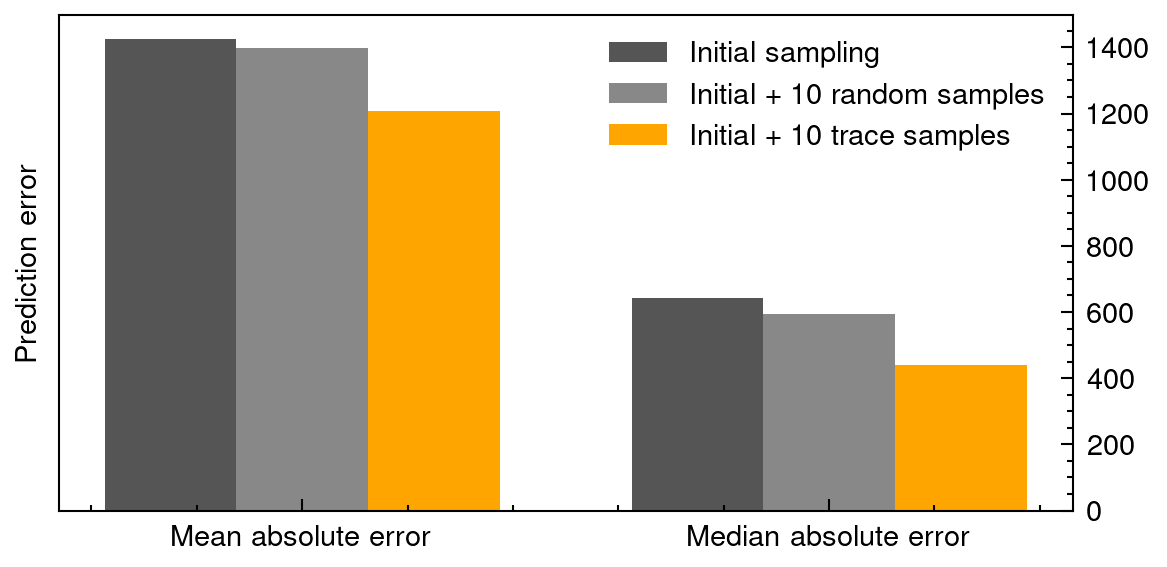

In [41]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['Base', 'Random', 'Trace']
metrics = ['Mean absolute error', 'Median absolute error']
colors = ['#555555', '#888888', 'orange']

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(4, 2))

for i, label in enumerate(labels):
    mae = tracing_pareto_prediction[f"{label.lower()}_mae"]
    mdae = tracing_pareto_prediction[f"{label.lower()}_mdae"]
    ax.bar(x[0] + i * width, mae, width, color=colors[i], label=f"{label}")
    ax.bar(x[1] + i * width, mdae, width, color=colors[i], label=f"{label}")

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel('Prediction error')
#ax.set_title('Prediction Error Comparison')
# Only show one legend entry per label
handles, labels_unique = [], []
for h, l in zip(*ax.get_legend_handles_labels()):
    l = {'Base': 'Initial sampling', 'Random': 'Initial + 10 random samples', 'Trace': 'Initial + 10 trace samples'}[l]
    if l not in labels_unique and l is not None:
        handles.append(h)
        labels_unique.append(l)
ax.legend(handles, labels_unique)
plt.tight_layout()
plt.show()


In [42]:
stash('figure4/tracing-pareto-prediction', fig)

## Wide range tracing

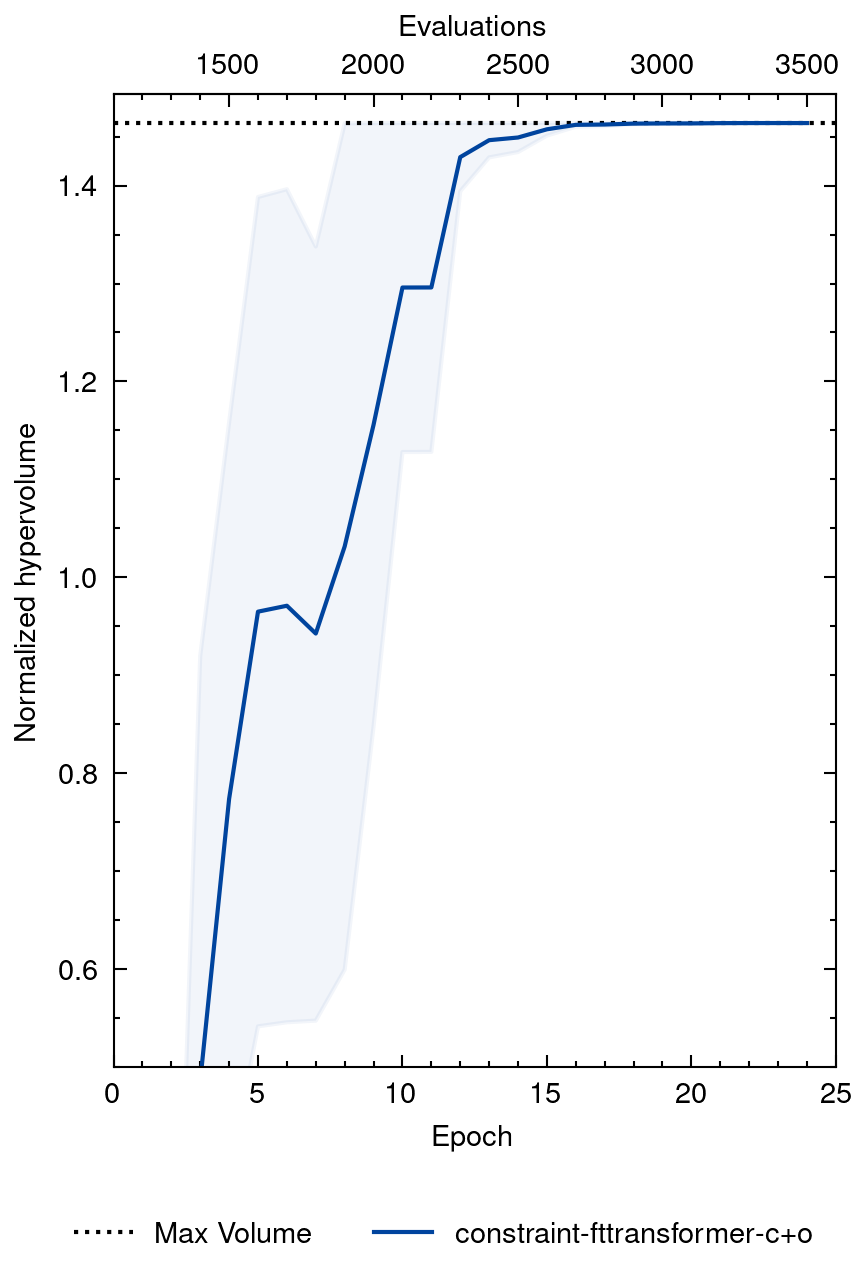

In [15]:
plt.rcParams["xtick.top"] = False
plt.rcParams["ytick.left"] = True
plt.rcParams["ytick.right"] = True
# plt.rcParams['axes.spines.top'] = False

plt.rcParams['ytick.labelright'] = False
plt.rcParams['ytick.labelleft'] = True


fig, ax = plt.subplots(1, 1, figsize=(3, 4))

p = 'MN'
models = mn_sopt_grad_hvs

nos_mean = np.mean(nos_hv[p + "10"])
nos_err = stats.sem(nos_hv[p + "10"])

ax.axhline(y=1.1**4, color="black", linestyle=":", label="Max Volume")

# determine when surrogate reaches within 1% of non-surrogate HV
converged = {}
for i, (model_name, epoch_hvs) in enumerate(models.items()):
    for epoch, hvs in epoch_hvs.items():
        epoch = int(epoch)
        converged[model_name] = [0]
        if epoch > 1 and np.mean(hvs) > 0.99 * np.mean(
            baseline_hvs[p]["baseline"]["24"]
        ):
            converged[model_name] = [(24-epoch)*100/(initial_samples[p]+100*24)*100]
            break

for i, (model_name, epoch_hvs) in enumerate(models.items()):
    if model_name != 'constraint-fttransformer-c+o':
        continue
    x = []
    y = []
    y_err = []
    yy = defaultdict(list)
    y_all = []
    for epoch, hvs in epoch_hvs.items():
        epoch = int(epoch)
        y_all.append(np.mean(hvs))
        if epoch == 0 or epoch > 100:
            continue
        x.append(int(epoch))
        y.append(np.mean(hvs))
        y_err.append(stats.sem(hvs))
        for q in range(len(hvs)):
            yy[q].append(hvs[q])

    y_err = np.array(y_err)
    y = np.array(y)

    l = {
        "objective constraint": "$\\nabla$(c+o)",
        "objective": "$\\nabla$(o)",
        "constraint": "$\\nabla$(c)",
        # "objective distance": 'od',
        #  "distance": 'd',
        #  "objective constraint distance": 'ocd',
    }[model_name.split('-')[0]]

    label = f"{l} ({ufloat(y[-1], y_err[-1]).n:.4f})"

    # ax.errorbar(x, y, yerr=y_err, label=model_name + f" ({ufloat(y[-1], y_err[-1])})", linestyle='-', capsize=1)
    ls_f = '-' # (0, (1,2))
    color = {
            "objective constraint": "#D5008F",
            "objective": "#137752",
            "constraint": "#00449E",
        }[model_name.split('-')[0]]
    ax.plot(
        np.array(x)[np.array(x) < 25],
        np.array(y)[np.array(x) < 25],
        color=color,
        label=model_name,
        linestyle="-" if 'resnet' not in model_name else '--'
    )

    ax.fill_between(x, y-y_err, y+y_err, alpha=0.05, color=color)

# igd
# axigd = inset_axes(
#     ax,
#     width="40%",
#     height="30%",
#     loc=f"lower right",
#     bbox_to_anchor=(0, 0.25, 1, 1),
#     bbox_transform=ax.transAxes,
# )
# sns.barplot(pd.DataFrame(igds[p]).drop("-", axis=1), ax=axigd)
# axigd.set_title("IGD", loc="right", y=1.0, pad=-6, fontsize=6)
# axigd.tick_params(top=False, bottom=False, left=True, right=True, labelsize=6)
# axigd.set_xticks([])
# axigd
# axigd.yaxis.tick_left()
# axigd.yaxis.set_label_position("left")

# # savings
# axsave = inset_axes(
#     ax,
#     width="40%",
#     height="30%",
#     loc=f"upper right",
#     bbox_to_anchor=(0, -0.1, 1, 1),
#     bbox_transform=ax.transAxes,
# )
# sns.barplot(pd.DataFrame(converged), ax=axsave)
# axsave.set_title("Evaluations saved (\\%)", loc="right", y=1.0, pad=-5, fontsize=6)
# axsave.tick_params(top=False, bottom=False, left=True, right=True, labelsize=6)
# axsave.set_xticks([])
# axsave.set_ylim([0, 100])#25.5])
#axsave.set_yticks([0, 10, 20, 25])

# ax.axhline(y=nos_mean, color="red", linestyle=":", label=f"NoS ({ufloat(nos_mean, nos_err)})")
# ax.fill_between(x, [nos_mean - nos_err] * len(x), [nos_mean + nos_err] * len(x), color="red", alpha=0.1)

# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel("Epoch")
ax.set_xlim([0, 25])

# ax.legend(loc='best')
ax.tick_params(top=False)

secax = ax.secondary_xaxis(
    "top",
    functions=(
        lambda x, ins=initial_samples[p]: x * 100 + ins,
        lambda x, ins=initial_samples[p]: (x + ins) / 100,
    ),
)
secax.set_xlabel("Evaluations")

# ax.set_ylim(0, 1.1**4 * 1.05)

ax.set_ylim([0.5, 1.1**4 + 0.03])

    
ax.set_ylabel("Normalized hypervolume")

ax.set_xlim([0, 25])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(labels), 
           bbox_to_anchor=(0.95, -0.01))
#fig.legend(bbox_to_anchor=(0.95, -0.01))

plt.tight_layout()
plt.show()

In [16]:
stash('figure4/tracing-hv-convergence', fig)

# Sgrad vs optimizers

In [46]:
_mn_optimizers = get("interface._mn_optimizers")

globus_download(_mn_optimizers)

In [47]:
_mn_sgrad = get("interface._mn_sgrad")

globus_download(_mn_sgrad)

In [48]:
mn_sgrad_vs_optimizers_hvs = {}

optimizers = _mn_optimizers.components.filter(
    lambda x: x.cached() and not x.load_attribute("preflight", False)
)
optimizers_nadir = fronts_nadir(optimizers)

sgrads = _mn_sgrad.components.filter(
    lambda x: x.cached() and not x.load_attribute("preflight", False)
)
sgrad_nadir = fronts_nadir(sgrads)

sopts = get("interface._mn_sopt_baseline", {'ranges': False}).components.filter(
    lambda x: x.cached() and not x.load_attribute("preflight", False)
)
sopt_nadir = fronts_nadir(sopts)

nadir = [float(max(a,max(b, c))) for a,b,c in zip(optimizers_nadir, sgrad_nadir, sopt_nadir)]

surrogate_names = set()
optimizer_names = set()

for experiments, key in [(optimizers, 'opt'), (sgrads, 'sgrad'), (sopts, 'baseline')]:
    for experiment in experiments:

        if key == "opt":
            surrogate_name = experiment.surrogate_method_name
            optimizer_name = experiment.config.dopt_params.optimizer_name
        elif key == "sgrad":
            surrogate_name = experiment.surrogate_method_name #experiment.custom_training_kwargs.get('mode')
            optimizer_name = 'sgrad'
        elif key == 'baseline':
            surrogate_name = experiment.surrogate_method_name
            optimizer_name = 'nsga2'

        if surrogate_name is None:
            continue
        if 'joint' in surrogate_name:
            surrogate_name = surrogate_name.replace('joint', experiment.backbone)

        surrogate_names.add(surrogate_name)
        optimizer_names.add(optimizer_name)
        model_name = f"{surrogate_name}_{optimizer_name}"

        epoch_ranges = experiment.epoch_ranges(from_zero=True)

        mn_sgrad_vs_optimizers_hvs.setdefault(model_name, {})
        for epoch, region in enumerate(epoch_ranges):
            if epoch > 9:
                continue
            mn_sgrad_vs_optimizers_hvs[model_name].setdefault(epoch, [])
            hv = experiment.norm_hv_region(nadir, region)
            mn_sgrad_vs_optimizers_hvs[model_name][epoch].append(hv)

mn_sgrad_vs_optimizers_auc = compute_auc_hvs({'MN': mn_sgrad_vs_optimizers_hvs})['MN']

# first 10 epochs
# mn_sgrad_vs_optimizers_hvs_norm = {
#     k: {str(i): v[str(i)] for i in range(10)} for k, v in mn_sgrad_vs_optimizers_hvs.items()
# }

In [49]:
stash("figure4-mn_sgrad_vs_optimizers_hvs", mn_sgrad_vs_optimizers_hvs)
stash("figure4-mn_sgrad_vs_optimizers_auc", mn_sgrad_vs_optimizers_auc)
stash("figure4-surrogate_names", list(surrogate_names))
stash("figure4-optimizer_names", list(optimizer_names))

In [53]:
mn_sgrad_vs_optimizers_hvs = restore("figure4-mn_sgrad_vs_optimizers_hvs")
mn_sgrad_vs_optimizers_auc = restore("figure4-mn_sgrad_vs_optimizers_auc")
surrogate_names = set(restore("figure4-surrogate_names"))
optimizer_names = set(restore("figure4-optimizer_names"))

In [54]:
from uncertainties import ufloat
maximum_auc = (1.1**4)*9
emperical_max = max(sum(mn_sgrad_vs_optimizers_auc.values(), start=[]))

mn_sgrad_vs_optimizers_auc_norm = {
    k: ufloat(np.mean(np.array(v)/maximum_auc), 
              np.std(np.array(v)/maximum_auc)) for k, v in mn_sgrad_vs_optimizers_auc.items()
}

mn_sgrad_vs_optimizers_auc_norm

{'gpr_age': 0.9740571447545445+/-0.02042773282407208,
 'megp_age': 0.9831525906151809+/-0.011720037593079135,
 'resnet-o_age': 0.9831651188236417+/-0.011697069386515187,
 'resnet-c+o_age': 0.9734900538371427+/-0.021991921214809966,
 'fttransformer-o_age': 0.9721568101337467+/-0.01670605536645469,
 'fttransformer-c+o_age': 0.9829449276804428+/-0.011703278357469303,
 'gpr_smpso': 0.9830675954196355+/-0.011743850992158685,
 'megp_smpso': 0.981819768197011+/-0.012446028901785705,
 'resnet-o_smpso': 0.9824637237853922+/-0.012164409760542729,
 'resnet-c+o_smpso': 0.9822915629231952+/-0.010531404827130268,
 'fttransformer-o_smpso': 0.9829745504388757+/-0.01177365013213976,
 'fttransformer-c+o_smpso': 0.9825071355064122+/-0.01178712350443483,
 'fttransformer-o_sgrad': 0.9593890253161043+/-0.047357487426285705,
 'fttransformer-c+o_sgrad': 0.9796058373430088+/-0.023271889327554023,
 'resnet-o_sgrad': 0.9911536778040152+/-0.005766631682353721,
 'resnet-c+o_sgrad': 0.9886065184522356+/-0.009812738

In [55]:
import pandas as pd

table = pd.DataFrame(
    index=sorted(surrogate_names),
    columns=sorted(optimizer_names)
)

for model_key, value in mn_sgrad_vs_optimizers_auc_norm.items():
    for surrogate in surrogate_names:
        for optimizer in optimizer_names:
            if model_key.startswith(surrogate) and model_key.endswith(optimizer):
                table.loc[surrogate, optimizer] = value


row_means = table.map(lambda x: x.n if x is not np.nan else np.nan).mean(axis=1)
col_means = table.map(lambda x: x.n if x is not np.nan else np.nan).mean(axis=0)

sorted_rows = row_means.sort_values(ascending=False).index
sorted_cols = col_means.sort_values(ascending=False).index

#table = table.loc[sorted_rows, sorted_cols]
table

,age,nsga2,sgrad,smpso
fttransformer-c+o,0.983+/-0.012,0.983+/-0.012,0.980+/-0.023,0.983+/-0.012
fttransformer-o,0.972+/-0.017,0.973+/-0.022,0.96+/-0.05,0.983+/-0.012
gpr,0.974+/-0.020,0.983+/-0.012,NaN,0.983+/-0.012
megp,0.983+/-0.012,0.983+/-0.012,NaN,0.982+/-0.012
resnet-c+o,0.973+/-0.022,0.983+/-0.012,0.989+/-0.010,0.982+/-0.011
resnet-o,0.983+/-0.012,0.983+/-0.012,0.991+/-0.006,0.982+/-0.012


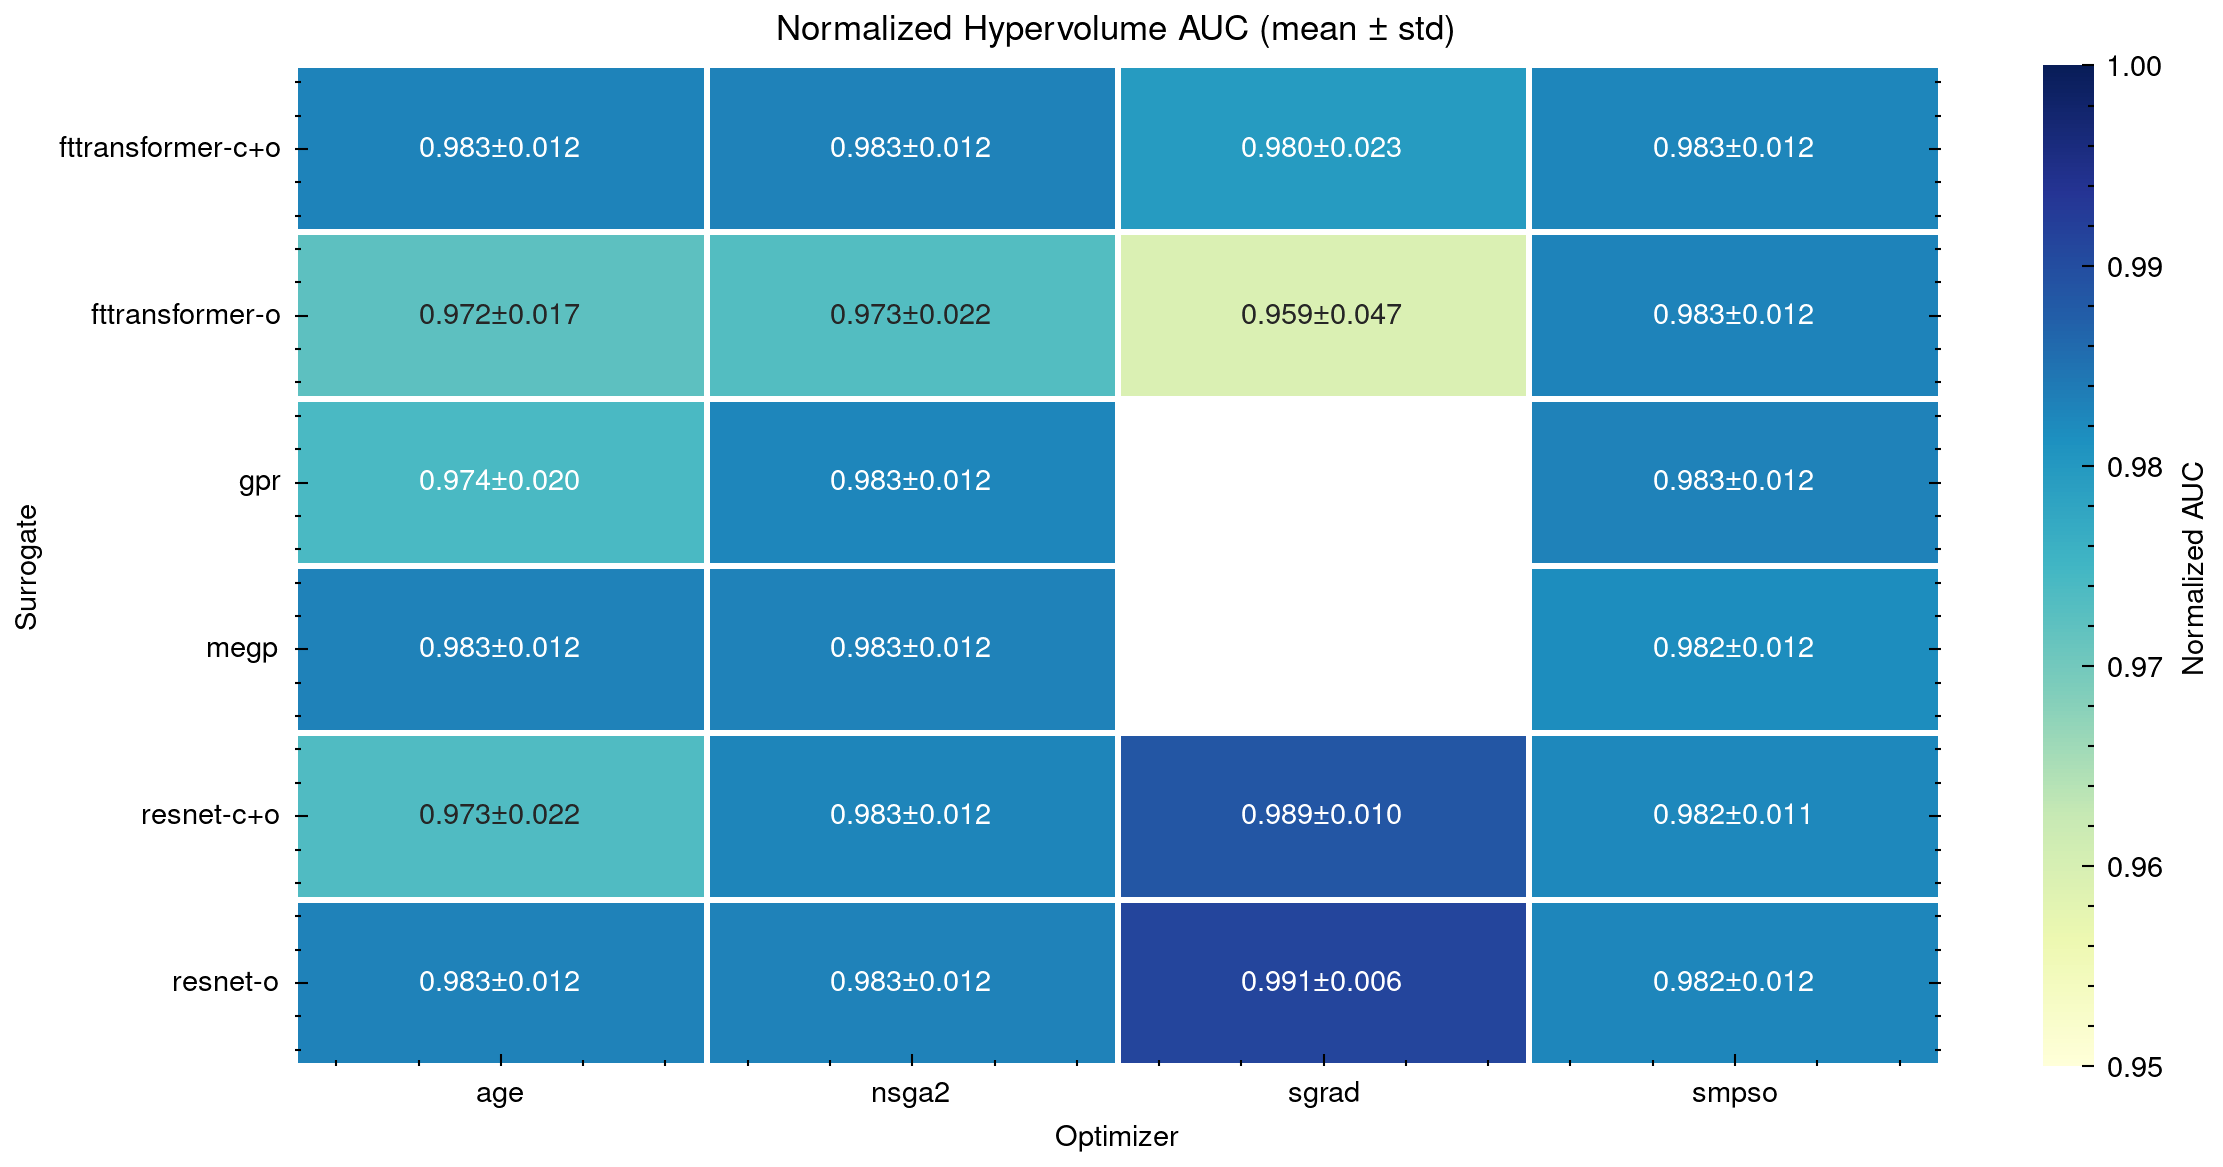

In [57]:
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

heatmap_data = table.map(lambda x: x.n if x is not np.nan else np.nan)
heatmap_err = table.map(lambda x: x.s if x is not np.nan else np.nan)

fig = plt.figure(figsize=(8, 4))
ax = sns.heatmap(
    heatmap_data.astype(float),
    annot=table.map(lambda x: f"{x.n:.3f}±{x.s:.3f}" if x is not np.nan else ""),
    fmt="",
    cmap="YlGnBu",
    vmin=0.95,
    vmax=1.0,
    cbar_kws={'label': 'Normalized AUC'},
    linewidths=1,
)
plt.title("Normalized Hypervolume AUC (mean ± std)")
plt.ylabel("Surrogate")
plt.xlabel("Optimizer")
plt.tight_layout()
plt.show()

In [58]:
stash('figure4/sgrad-vs-optimizer', fig)